# Información inicial

- Universidad de Buenos Aires
- Especialización en Inteligencia Artificial
- Probabilidad y Estadística para la Inteligencia Artificial
- *Docente:* Camilo Argoty
- *Alumno:* Rodrigo Hernández Código: a2526
- *Fecha:* 28/05/26

# Punto 1

De 10 monedas hay 4 monedas falsas, que tienen probabilidad $0{,}9$ de mostrar cara al ser lanzadas. Si se toma una moneda al azar, se lanza 16 veces, y en todas ellas se obtiene cara, ¿qué es más probable, que la moneda elegida sea justa o que esté cargada? Dar las probabilidades tanto de que la moneda elegida sea falsa, como de que sea justa.

## Respuesta al punto 1

### Definición de eventos

Sean los siguientes eventos:

- $A$: "salieron 16 caras en los 16 lanzamientos" (lo observado)
- $B_1$: "la moneda elegida es **falsa** (cargada)"
- $B_2$: "la moneda elegida es **justa**"


### Fórmula de Bayes

$$
P(B_j \mid A) = \frac{P(A \mid B_j)\, P(B_j)}{\sum_i P(A \mid B_i)\, P(B_i)}
$$

### Cálculo de los priors $P(B_j)$

Como la moneda se toma al azar de un conjunto de 10 monedas equiprobables, por la regla de Laplace:

$$
P(B_1) = \frac{4}{10} = 0{,}4 \qquad P(B_2) = \frac{6}{10} = 0{,}6
$$


### Cálculo de las verosimilitudes $P(A \mid B_j)$

Los lanzamientos son independientes, por lo tanto la probabilidad de observar 16 caras seguidas es el producto de las probabilidades individuales de cada tiro:

$$
P(A \mid B_1) = \underbrace{0{,}9 \cdot 0{,}9 \cdots 0{,}9}_{16 \text{ veces}} = 0{,}9^{16} \approx 0{,}18530
$$

$$
P(A \mid B_2) = \underbrace{0{,}5 \cdot 0{,}5 \cdots 0{,}5}_{16 \text{ veces}} = 0{,}5^{16} \approx 1{,}526 \times 10^{-5}
$$

### Cálculo del denominador (teorema de probabilidad total)

El denominador de la fórmula de Bayes es justamente la probabilidad total de observar $A$. El **teorema de la probabilidad total** dice que, si $B_1, B_2, \dots, B_n$ forman una partición del espacio muestral, entonces:

$$
P(A) = \sum_i P(A \mid B_i)\, P(B_i)
$$

En nuestro caso, como $B_1$ (falsa) y $B_2$ (justa) son las únicas dos hipótesis posibles, la sumatoria tiene dos términos:

$$
P(A) = P(A \mid B_1)\, P(B_1) + P(A \mid B_2)\, P(B_2)
$$

Reemplazando los valores:

$$
P(A) = 0{,}9^{16} \cdot 0{,}4 \;+\; 0{,}5^{16} \cdot 0{,}6 \;\approx\; 0{,}074118 + 0{,}00000916 \;\approx\; 0{,}074128
$$

### Aplicación de la fórmula para $j = 1$ (moneda falsa)

$$
P(B_1 \mid A) = \frac{P(A \mid B_1)\, P(B_1)}{\sum_i P(A \mid B_i)\, P(B_i)} = \frac{0{,}9^{16} \cdot 0{,}4}{0{,}9^{16} \cdot 0{,}4 + 0{,}5^{16} \cdot 0{,}6}
$$

$$
\approx \frac{0{,}074118}{0{,}074128} \approx 0{,}999876
$$

### Aplicación de la fórmula para $j = 2$ (moneda justa)

$$
P(B_2 \mid A) = \frac{P(A \mid B_2)\, P(B_2)}{\sum_i P(A \mid B_i)\, P(B_i)} = \frac{0{,}5^{16} \cdot 0{,}6}{0{,}9^{16} \cdot 0{,}4 + 0{,}5^{16} \cdot 0{,}6}
$$

$$
\approx \frac{0{,}00000916}{0{,}074128} \approx 0{,}000124
$$

### Verificación

$$
P(B_1 \mid A) + P(B_2 \mid A) \approx 0{,}999876 + 0{,}000124 = 1 \quad \checkmark
$$

### Conclusión

| Hipótesis        | Probabilidad posterior        |
|------------------|-------------------------------|
| Moneda **falsa** | $\approx 0{,}9999$ (99,99 %)  |
| Moneda **justa** | $\approx 0{,}0001$ (0,01 %)   |

**Es muchísimo más probable que la moneda elegida esté cargada.**

In [34]:
# Comprobación del Punto 1
#
# Verificamos con la fórmula de Bayes.

import numpy as np

# --- Datos del enunciado ---
n_monedas      = 10
n_falsas       = 4
n_justas       = n_monedas - n_falsas
p_cara_falsa   = 0.9
p_cara_justa   = 0.5
n_tiros        = 16
caras_obs      = 16

# --- (1) Cálculo analítico con Bayes ---
P_B1 = n_falsas / n_monedas          # prior moneda falsa
P_B2 = n_justas / n_monedas          # prior moneda justa

P_A_dado_B1 = p_cara_falsa ** caras_obs   # verosimilitud bajo falsa
P_A_dado_B2 = p_cara_justa ** caras_obs   # verosimilitud bajo justa

# Denominador: probabilidad total de A
P_A = P_A_dado_B1 * P_B1 + P_A_dado_B2 * P_B2

# Posteriors
P_B1_dado_A = (P_A_dado_B1 * P_B1) / P_A
P_B2_dado_A = (P_A_dado_B2 * P_B2) / P_A

print("=== Cálculo analítico (Bayes) ===")
print(f"P(A | falsa)         = 0.9^16   = {P_A_dado_B1:.8f}")
print(f"P(A | justa)         = 0.5^16   = {P_A_dado_B2:.8e}")
print(f"P(A) (prob. total)              = {P_A:.8f}")
print(f"P(falsa | 16 caras)             = {P_B1_dado_A:.8f}  ({P_B1_dado_A*100:.4f} %)")
print(f"P(justa | 16 caras)             = {P_B2_dado_A:.8f}  ({P_B2_dado_A*100:.4f} %)")
print(f"Suma de posteriors              = {P_B1_dado_A + P_B2_dado_A:.8f}")

=== Cálculo analítico (Bayes) ===
P(A | falsa)         = 0.9^16   = 0.18530202
P(A | justa)         = 0.5^16   = 1.52587891e-05
P(A) (prob. total)              = 0.07412996
P(falsa | 16 caras)             = 0.99987650  (99.9876 %)
P(justa | 16 caras)             = 0.00012350  (0.0124 %)
Suma de posteriors              = 1.00000000


# Punto 2

Sean X e Y dos v.a. continuas con densidad conjunta:

$$
f_{X,Y} = \begin{cases} Ky & 16x^2 \leq y \leq 2x \\ 0 & \text{en otro caso} \end{cases}
$$

Encontrar:

a) Determine el valor de $K$

b) Encuentre la densidad marginal $f_X(x)$ de $X$

c) Encuentre la densidad marginal $f_Y(y)$ de $Y$

d) Encuentre la densidad condicional $f_{X|Y}(x|y)$ de $X$ dado $Y$

e) Encuentre la densidad condicional $f_{Y|X}(y|x)$ de $Y$ dado $X$

## Respuesta al punto 2

### Región de soporte

La densidad vale $Ky$ sólo donde $16x^2 \leq y \leq 2x$. Las dos curvas que delimitan la región son:

- $y = 16x^2$ (parábola que abre hacia arriba)
- $y = 2x$ (recta por el origen con pendiente 2)

**Puntos de intersección:** igualando $16x^2 = 2x \;\Rightarrow\; 2x(8x - 1) = 0 \;\Rightarrow\; x = 0$ o $x = 1/8$.

Probando un punto intermedio (por ejemplo $x = 1/16$) vemos que la recta está por encima de la parábola en ese intervalo. Por lo tanto la región es la franja entre la parábola y la recta, con:

$$
x \in [0,\ 1/8] \qquad \text{y} \qquad y \in [0,\ 1/4]
$$

La región $S$ admite dos descripciones equivalentes:

$$
\begin{aligned}
\text{(A)} &\quad x \in [0,\ 1/8], \quad y \in [16x^2,\ 2x] \\
\text{(B)} &\quad y \in [0,\ 1/4], \quad x \in \left[\tfrac{y}{2},\ \tfrac{\sqrt{y}}{4}\right]
\end{aligned}
$$

---

### a) Valor de $K$

Partimos de la propiedad de normalización de toda densidad conjunta:

$$
1 \;=\; \iint_S f_{X,Y}(x,y)\, dA \;=\; \int_a^b f_X(x)\, dx
$$

Usando la descripción (A) de la región, esta condición se escribe como una integral iterada:

$$
\int_0^{1/8} \int_{16x^2}^{2x} K y \, dy\, dx \;=\; 1
$$

**Integral interior:**

$$
\int_{16x^2}^{2x} K y \, dy = K \cdot \frac{y^2}{2} \bigg|_{16x^2}^{2x} = \frac{K}{2}\Big[(2x)^2 - (16x^2)^2\Big] = \frac{K}{2}(4x^2 - 256 x^4)
$$

**Integral exterior:**

$$
\int_0^{1/8} \frac{K}{2}(4x^2 - 256 x^4)\, dx = \frac{K}{2}\left[\frac{4x^3}{3} - \frac{256 x^5}{5}\right]_0^{1/8}
$$

Evaluando en $x = 1/8$:

$$
\frac{4 \cdot (1/8)^3}{3} = \frac{1}{384}, \qquad \frac{256 \cdot (1/8)^5}{5} = \frac{1}{640}
$$

$$
\frac{1}{384} - \frac{1}{640} = \frac{5}{1920} - \frac{3}{1920} = \frac{2}{1920} = \frac{1}{960}
$$

Por lo tanto:

$$
\frac{K}{2} \cdot \frac{1}{960} = \frac{K}{1920} = 1
$$

$$
\boxed{K = 1920}
$$

---

### b) Densidad marginal $f_X(x)$

Partimos de la fórmula de la densidad marginal de $X$ a partir de la conjunta:

$$
f_X(x) \;=\; \int_{c(x)}^{d(x)} f_{X,Y}(x,y)\, dy
$$

donde $c(x)$ y $d(x)$ son los límites del soporte para cada $x$ fijo. En nuestro caso $c(x) = 16x^2$ y $d(x) = 2x$:

$$
f_X(x) = \int_{16x^2}^{2x} 1920\, y \, dy = 1920 \cdot \frac{y^2}{2} \bigg|_{16x^2}^{2x} = 960\Big[(2x)^2 - (16x^2)^2\Big] = 960\,(4x^2 - 256 x^4)
$$

$$
\boxed{f_X(x) = 3840\, x^2\,(1 - 64 x^2), \quad x \in [0,\ 1/8]}
$$

y $f_X(x) = 0$ fuera de ese intervalo.

---

### c) Densidad marginal $f_Y(y)$

De manera análoga, la marginal de $Y$ se obtiene integrando la conjunta respecto de $x$:

$$
f_Y(y) \;=\; \int_{a(y)}^{b(y)} f_{X,Y}(x,y)\, dx
$$

Usando la descripción (B) de la región, $a(y) = y/2$ y $b(y) = \sqrt{y}/4$:

$$
f_Y(y) = \int_{y/2}^{\sqrt{y}/4} 1920\, y \, dx
$$

Dentro de esta integral $y$ es constante (la variable de integración es $x$), así que sale afuera:

$$
f_Y(y) = 1920\, y \cdot \left(\frac{\sqrt{y}}{4} - \frac{y}{2}\right) = 1920\, y \cdot \frac{\sqrt{y} - 2y}{4} = 480\, y\,(\sqrt{y} - 2y)
$$

$$
\boxed{f_Y(y) = 480\, y^{3/2} - 960\, y^2, \quad y \in [0,\ 1/4]}
$$

y $f_Y(y) = 0$ fuera de ese intervalo.

**Verificación:**

$$
\int_0^{1/4} (480\, y^{3/2} - 960\, y^2)\, dy = \big[192\, y^{5/2} - 320\, y^3\big]_0^{1/4} = 192 \cdot \tfrac{1}{32} - 320 \cdot \tfrac{1}{64} = 6 - 5 = 1 \;\checkmark
$$

---

### d) Densidad condicional $f_{X \mid Y}(x \mid y)$

Partimos de la fórmula de la densidad condicional:

$$
f_{X \mid Y}(x \mid y) \;=\; \frac{f_{X,Y}(x,y)}{f_Y(y)}
$$

Sustituyendo:

$$
f_{X \mid Y}(x \mid y) = \frac{1920\, y}{480\, y^{3/2} - 960\, y^2}
$$

Factorizando el denominador como $480\, y\,(\sqrt{y} - 2y)$:

$$
f_{X \mid Y}(x \mid y) = \frac{1920\, y}{480\, y\,(\sqrt{y} - 2y)} = \frac{4}{\sqrt{y} - 2y}
$$

$$
\boxed{f_{X \mid Y}(x \mid y) = \frac{4}{\sqrt{y} - 2y}, \quad x \in \left[\tfrac{y}{2},\ \tfrac{\sqrt{y}}{4}\right]}
$$

**Observación:** la expresión **no depende de $x$**, por lo tanto la distribución de $X$ dado $Y = y$ es **uniforme** en el intervalo $\left[\tfrac{y}{2},\ \tfrac{\sqrt{y}}{4}\right]$. Esto es consistente con que la conjunta $f_{X,Y}(x,y) = Ky$ tampoco depende de $x$: fijando $y$, todos los $x$ del soporte son igualmente probables.

---

### e) Densidad condicional $f_{Y \mid X}(y \mid x)$

Análogamente, la condicional de $Y$ dado $X$ es:

$$
f_{Y \mid X}(y \mid x) \;=\; \frac{f_{X,Y}(x,y)}{f_X(x)}
$$

Sustituyendo:

$$
f_{Y \mid X}(y \mid x) = \frac{1920\, y}{3840\, x^2\,(1 - 64 x^2)}
$$

Simplificando $1920/3840 = 1/2$:

$$
\boxed{f_{Y \mid X}(y \mid x) = \frac{y}{2\, x^2\,(1 - 64 x^2)}, \quad y \in [16 x^2,\ 2x]}
$$

**Observación:** a diferencia de la condicional anterior, esta **sí depende de $y$** (es lineal en $y$). Esto significa que, dado un valor de $X = x$, los valores grandes de $y$ dentro del intervalo $[16x^2, 2x]$ son más probables que los chicos.

**Verificación:**

$$
\int_{16x^2}^{2x} \frac{y}{2x^2(1-64x^2)}\, dy = \frac{1}{2x^2(1-64x^2)} \cdot \frac{y^2}{2}\bigg|_{16x^2}^{2x} = \frac{4x^2 - 256 x^4}{4x^2(1-64x^2)} = \frac{4x^2(1-64x^2)}{4x^2(1-64x^2)} = 1 \;\checkmark
$$

---

### Resumen

| Ítem | Resultado | Soporte |
|------|-----------|---------|
| a    | $K = 1920$ | — |
| b    | $f_X(x) = 3840\, x^2\,(1 - 64 x^2)$ | $x \in [0,\ 1/8]$ |
| c    | $f_Y(y) = 480\, y^{3/2} - 960\, y^2$ | $y \in [0,\ 1/4]$ |
| d    | $f_{X\mid Y}(x \mid y) = \dfrac{4}{\sqrt{y} - 2y}$ (uniforme) | $x \in \left[\tfrac{y}{2},\ \tfrac{\sqrt{y}}{4}\right]$ |
| e    | $f_{Y\mid X}(y \mid x) = \dfrac{y}{2 x^2\,(1 - 64 x^2)}$ | $y \in [16 x^2,\ 2x]$ |

# Punto 3

Sea:

$$
Y = R \cos(2\pi \cdot \Phi),
$$

donde $R$ y $\Phi$ son variables aleatorias independientes. La fase $\Phi$ se distribuye uniforme sobre el intervalo $(0, 1)$, mientras que la amplitud $R$ tiene una distribución de Rayleigh con densidad $f(r) = r e^{-r^2/2}$ para $r > 0$. Muestre que $Y$ tiene una distribución normal.

**Pista:** Defina $Y = R \operatorname{sen}(2\pi \cdot \Phi)$ y $X = R \cos(2\pi \cdot \Phi)$ y utilice la relación $X^2 + Y^2 = R^2$ para calcular la densidad conjunta de $(X, Y)$ a partir de la densidad conjunta de $(R, \Phi)$.

## Respuesta al punto 3

### Planteo

Sean $R$ y $\Phi$ variables aleatorias independientes con:

- $R$ con distribución de Rayleigh: $f_R(r) = r\, e^{-r^2/2}$ para $r > 0$.
- $\Phi$ con distribución uniforme en $(0, 1)$: $f_\Phi(\varphi) = 1$ para $\varphi \in (0, 1)$.

**Aplicando la pista del enunciado**, definimos las dos variables transformadas:

$$
X = R \cos(2\pi \Phi) \qquad Y = R \operatorname{sen}(2\pi \Phi)
$$

Notamos que estas variables satisfacen la **relación geométrica clave** que indica la pista:

$$
X^2 + Y^2 = R^2 \cos^2(2\pi\Phi) + R^2 \operatorname{sen}^2(2\pi\Phi) = R^2,
$$

que vamos a usar más adelante para re-expresar la densidad conjunta de $(X, Y)$ en términos de $(x, y)$ una vez que la obtengamos. El objetivo es mostrar que $X$ (e $Y$, por simetría) tiene distribución normal estándar.

### Densidad conjunta de $(R, \Phi)$

Como $R$ y $\Phi$ son independientes, la densidad conjunta es el producto de las marginales:

$$
f_{R, \Phi}(r, \varphi) = f_R(r) \cdot f_\Phi(\varphi) = r\, e^{-r^2/2} \quad \text{para } r > 0,\ \varphi \in (0, 1)
$$

### Fórmula para la densidad conjunta transformada

Para obtener la densidad conjunta de $(X, Y)$ a partir de la conjunta de $(R, \Phi)$, aplicamos la fórmula para la distribución conjunta transformada. Como la transformación $(R, \Phi) \to (X, Y)$ está dada directamente por funciones elementales:

$$
x = r \cos(2\pi \varphi) \qquad y = r \operatorname{sen}(2\pi \varphi)
$$

resulta más cómodo trabajar con esta forma directa de la fórmula:

$$
f_{X, Y}(x, y) = \frac{f_{R, \Phi}(r, \varphi)}{\left| \dfrac{\partial x}{\partial r} \cdot \dfrac{\partial y}{\partial \varphi} - \dfrac{\partial x}{\partial \varphi} \cdot \dfrac{\partial y}{\partial r} \right|}
$$

### Cálculo de las derivadas parciales

A partir de $x = r \cos(2\pi \varphi)$ y $y = r \operatorname{sen}(2\pi \varphi)$:

$$
\frac{\partial x}{\partial r} = \cos(2\pi \varphi) \qquad \frac{\partial x}{\partial \varphi} = -2\pi r \operatorname{sen}(2\pi \varphi)
$$

$$
\frac{\partial y}{\partial r} = \operatorname{sen}(2\pi \varphi) \qquad \frac{\partial y}{\partial \varphi} = 2\pi r \cos(2\pi \varphi)
$$

### Cálculo del factor de transformación

Combinando las derivadas:

$$
\left| \frac{\partial x}{\partial r} \cdot \frac{\partial y}{\partial \varphi} - \frac{\partial x}{\partial \varphi} \cdot \frac{\partial y}{\partial r} \right|
$$

$$
= \left| \cos(2\pi \varphi) \cdot 2\pi r \cos(2\pi \varphi) - \bigl(-2\pi r \operatorname{sen}(2\pi \varphi)\bigr) \cdot \operatorname{sen}(2\pi \varphi) \right|
$$

$$
= \left| 2\pi r \bigl(\cos^2(2\pi \varphi) + \operatorname{sen}^2(2\pi \varphi)\bigr) \right| = 2\pi r
$$

(En el último paso usamos la identidad pitagórica $\cos^2 + \operatorname{sen}^2 = 1$.)

### Sustitución y simplificación

Reemplazando en la fórmula de la conjunta transformada:

$$
f_{X, Y}(x, y) = \frac{f_{R, \Phi}(r, \varphi)}{2\pi r} = \frac{r\, e^{-r^2/2}}{2\pi r} = \frac{e^{-r^2/2}}{2\pi}
$$

**Aplicando ahora la relación de la pista** $X^2 + Y^2 = R^2$, reemplazamos $r^2 = x^2 + y^2$ para expresar la densidad conjunta enteramente en términos de las nuevas variables:

$$
\boxed{f_{X, Y}(x, y) = \frac{1}{2\pi}\, e^{-(x^2 + y^2)/2} \qquad \text{para } (x, y) \in \mathbb{R}^2}
$$

### Factorización como producto de marginales

Separando el exponente y el factor $2\pi$:

$$
f_{X, Y}(x, y) = \underbrace{\frac{1}{\sqrt{2\pi}}\, e^{-x^2/2}}_{f_X(x)} \cdot \underbrace{\frac{1}{\sqrt{2\pi}}\, e^{-y^2/2}}_{f_Y(y)}
$$

Como la densidad conjunta factoriza como producto de las marginales, $X$ e $Y$ son **independientes**, y cada una tiene densidad

$$
f_X(x) = \frac{1}{\sqrt{2\pi}}\, e^{-x^2/2}, \qquad f_Y(y) = \frac{1}{\sqrt{2\pi}}\, e^{-y^2/2}
$$

que es precisamente la densidad de una distribución normal estándar $\mathcal{N}(0, 1)$.

### Conclusión

$$
X = R \cos(2\pi \Phi) \sim \mathcal{N}(0, 1) \qquad Y = R \operatorname{sen}(2\pi \Phi) \sim \mathcal{N}(0, 1)
$$

Por lo tanto, **$Y = R \cos(2\pi \Phi)$ del enunciado tiene distribución normal estándar**.

# Punto 4

Don Francisco es un pequeño comerciante de barrio que posee un supermercado, con el que sostiene su familia. Uno de sus hijos, Matías, quien recién inicia a cursar la Especialización en Inteligencia Artificial del LSE de la UBA, le propone hacer un análisis de las ventas durante el año anterior, con el fin de hacer pronósticos para el año siguiente, lo que a don Francisco le parece buena idea.

Don Francisco le entrega a Matías el cuaderno donde tiene registrado el valor total de sus ventas en cada día del año. Con esta información, Matías construye una tabla en la cual la primera columna corresponde a la fecha y la segunda corresponde al monto de las ventas, en dólares para evitarse dolores de cabeza con la inflación. Matías no se siente muy seguro de la tarea a realizar, así que les pide ayuda a ustedes para abordar el problema.

Don Miguel, otro comerciante amigo de Don Francisco, se entera del análisis de Matías y le pide que también analice los datos de sus ventas.

## Consigna

**a)** Crear una simulación del número de clientes diarios que llegan a los de Don Francisco y de Don Miguel, usando distribuciones Poisson, entre los años 2023, 2024 y 2025. En cada fecha, el parámetro $\lambda_t$ debe ser la suma de los siguientes efectos:

**Efecto anual:**

| Año  | Efecto |
|------|--------|
| 2023 | 10     |
| 2024 | 15     |
| 2025 | 20     |

**Efecto mensual:**

| Mes        | Efecto |
|------------|--------|
| Enero      | 10     |
| Febrero    | 15     |
| Marzo      | 20     |
| Abril      | 20     |
| Mayo       | 25     |
| Junio      | 25     |
| Julio      | 30     |
| Agosto     | 25     |
| Septiembre | 25     |
| Octubre    | 20     |
| Noviembre  | 15     |
| Diciembre  | 10     |

**Efecto diario:**

| Día       | Efecto |
|-----------|--------|
| Domingo   | 10     |
| Lunes     | 20     |
| Martes    | 30     |
| Miércoles | 35     |
| Jueves    | 30     |
| Viernes   | 20     |
| Sábado    | 10     |

**Efecto local:**

| Propietario   | Efecto |
|---------------|--------|
| Don Francisco | 20     |
| Don Miguel    | 10     |

**b)** Con base en los datos generados, determine una función empírica de distribución y una aproximación a la función de densidad de las ventas del supermercado de Don Francisco para cada año de registro.

**c)** De igual manera, determine una función empírica de distribución y una aproximación a la función de densidad de las ventas del supermercado de Don Miguel para cada año de registro.

**d)** Determine una densidad empírica conjunta para ambos almacenes.

## Respuesta al punto 4

**Parte a — Simulación.** Generamos el número diario de clientes para Don Francisco y Don Miguel entre 2023 y 2025 usando una distribución de Poisson cuyo parámetro $\lambda_t$ se construye como la suma de los cuatro efectos del enunciado (anual, mensual, diario, local). La distribución de Poisson es la elección estándar para modelar conteos de eventos independientes en un intervalo de tiempo (clientes que entran a un local, llamadas a un call-center, autos que pasan por un peaje).

**Parte b y c — Distribuciones empíricas por año.** Para cada propietario y cada año de registro construimos:

- La **función empírica de distribución (ECDF)**: $\hat{F}(x) = \dfrac{\#\{\text{días con clientes} \leq x\}}{\text{total de días}}$. Usamos `sns.ecdfplot()`.
- Una **aproximación a la densidad** mediante histograma normalizado y KDE (Kernel Density Estimation). Usamos `sns.histplot()` y `sns.kdeplot()`.

**Parte d — Densidad conjunta empírica.** Para cada día emparejamos las observaciones de los dos comercios y obtenemos la densidad conjunta $\hat{f}_{X,Y}(x,y)$ con `sns.jointplot(kind="kde")`, que también muestra al costado las dos marginales.

In [35]:
# Parte a) — Simulación de clientes diarios
#
# Construimos λ_t para cada día y propietario como la suma de los cuatro
# efectos del enunciado, y sampleamos clientes ~ Poisson(λ_t).

import numpy as np
import pandas as pd

np.random.seed(42)

# Tablas de efectos (extraídas directo del enunciado)
EFECTO_ANUAL = {2023: 10, 2024: 15, 2025: 20}

EFECTO_MENSUAL = {
    1: 10, 2: 15, 3: 20, 4: 20, 5: 25, 6: 25,
    7: 30, 8: 25, 9: 25, 10: 20, 11: 15, 12: 10,
}

# pandas codifica el día de la semana como: 0=Lunes, 1=Martes, ..., 6=Domingo
EFECTO_DIARIO = {
    0: 20,  # Lunes
    1: 30,  # Martes
    2: 35,  # Miércoles
    3: 30,  # Jueves
    4: 20,  # Viernes
    5: 10,  # Sábado
    6: 10,  # Domingo
}

EFECTO_LOCAL = {"Don Francisco": 20, "Don Miguel": 10}

# Generamos todas las fechas del rango y construimos un registro por
# (fecha, propietario)
fechas = pd.date_range("2023-01-01", "2025-12-31", freq="D")

registros = []
for fecha in fechas:
    for propietario in ("Don Francisco", "Don Miguel"):
        lam = (
            EFECTO_ANUAL[fecha.year]
            + EFECTO_MENSUAL[fecha.month]
            + EFECTO_DIARIO[fecha.dayofweek]
            + EFECTO_LOCAL[propietario]
        )
        registros.append({
            "fecha": fecha,
            "anio": fecha.year,
            "propietario": propietario,
            "lambda": lam,
            "clientes": np.random.poisson(lam),
        })

df = pd.DataFrame(registros)

print(f"Total de registros: {len(df):,}")
print(f"Rango de fechas: {df['fecha'].min().date()} a {df['fecha'].max().date()}")
print("\nPrimeros 6 registros:")
print(df.head(6).to_string(index=False))
print("\nResumen estadístico de clientes por propietario:")
print(df.groupby("propietario")["clientes"].describe().round(1))


Total de registros: 2,192
Rango de fechas: 2023-01-01 a 2025-12-31

Primeros 6 registros:
     fecha  anio   propietario  lambda  clientes
2023-01-01  2023 Don Francisco      50        47
2023-01-01  2023    Don Miguel      40        44
2023-01-02  2023 Don Francisco      60        51
2023-01-02  2023    Don Miguel      50        52
2023-01-03  2023 Don Francisco      70        79
2023-01-03  2023    Don Miguel      60        52

Resumen estadístico de clientes por propietario:
                count  mean   std   min   25%   50%   75%    max
propietario                                                     
Don Francisco  1096.0  76.9  14.8  37.0  67.0  76.0  87.0  128.0
Don Miguel     1096.0  67.0  14.3  27.0  57.0  67.0  77.0  106.0


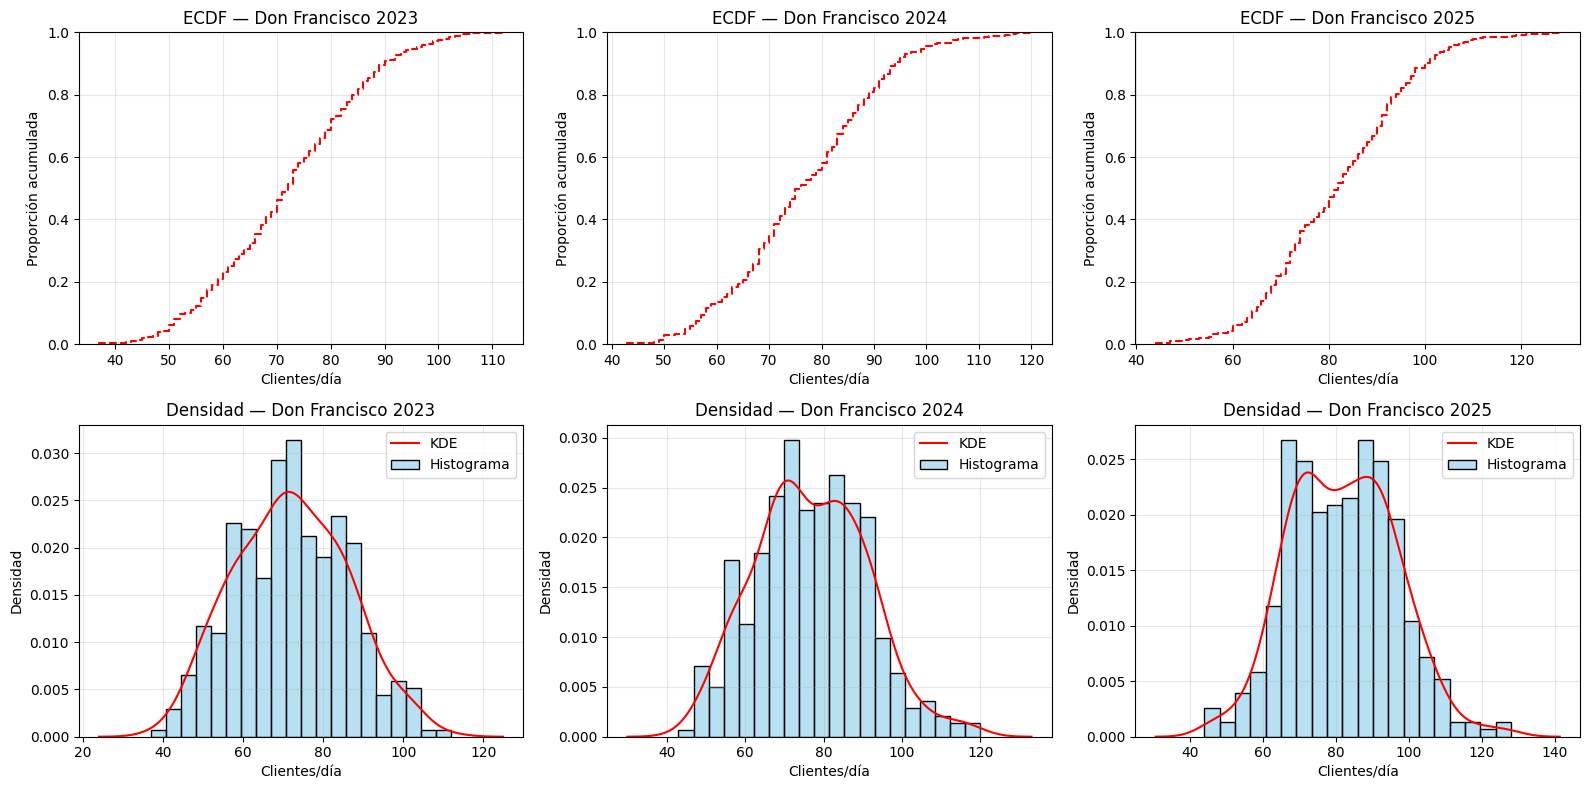


Media y desvío de clientes/día — Don Francisco por año:
       mean    std
anio              
2023  72.06  14.06
2024  76.82  14.15
2025  81.89  14.47


In [36]:
# Parte b) — Don Francisco: ECDF y aproximación a la densidad por año
#
# Para cada año (2023, 2024, 2025) graficamos:
#   - La función de distribución acumulada empírica (ECDF) con sns.ecdfplot
#   - El histograma normalizado + KDE con sns.histplot + sns.kdeplot

import matplotlib.pyplot as plt
import seaborn as sns

df_francisco = df[df["propietario"] == "Don Francisco"]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for j, anio in enumerate([2023, 2024, 2025]):
    datos = df_francisco.loc[df_francisco["anio"] == anio, "clientes"]

    # Fila 0: ECDF
    sns.ecdfplot(datos, ax=axes[0, j], color="red", linestyle="--")
    axes[0, j].set_title(f"ECDF — Don Francisco {anio}")
    axes[0, j].set_xlabel("Clientes/día")
    axes[0, j].set_ylabel("Proporción acumulada")
    axes[0, j].grid(alpha=0.3)

    # Fila 1: histograma normalizado (stat='density') + KDE encima
    sns.histplot(datos, bins=20, stat="density", ax=axes[1, j],
                 color="skyblue", alpha=0.6, label="Histograma")
    sns.kdeplot(datos, ax=axes[1, j], color="red", label="KDE")
    axes[1, j].set_title(f"Densidad — Don Francisco {anio}")
    axes[1, j].set_xlabel("Clientes/día")
    axes[1, j].set_ylabel("Densidad")
    axes[1, j].legend()
    axes[1, j].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nMedia y desvío de clientes/día — Don Francisco por año:")
print(df_francisco.groupby("anio")["clientes"].agg(["mean", "std"]).round(2))


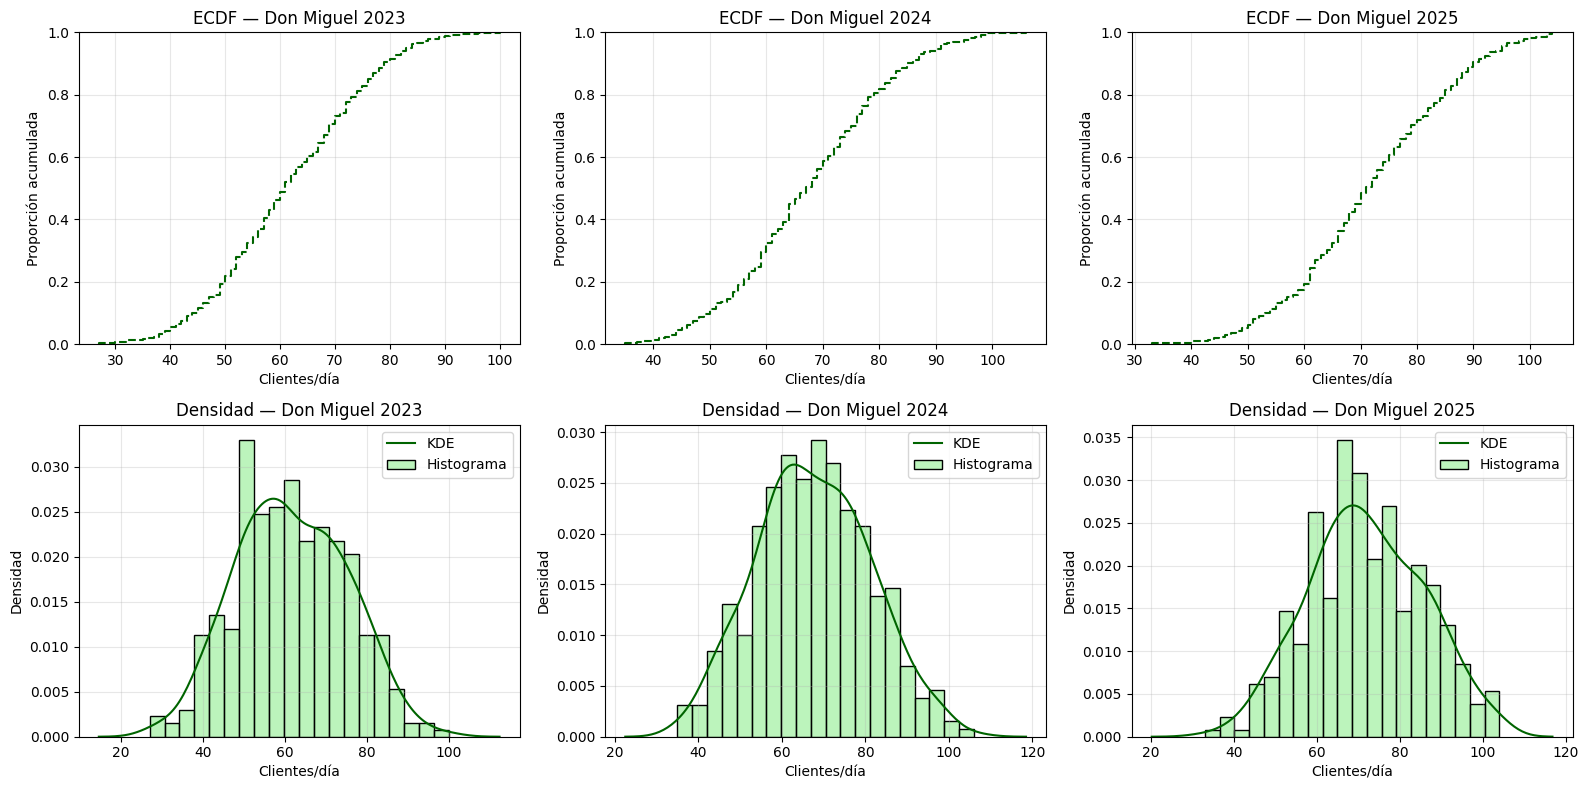


Media y desvío de clientes/día — Don Miguel por año:
       mean    std
anio              
2023  61.63  13.42
2024  67.56  13.54
2025  71.91  13.91


In [37]:
# Parte c) — Don Miguel: ECDF y aproximación a la densidad por año

import matplotlib.pyplot as plt
import seaborn as sns

df_miguel = df[df["propietario"] == "Don Miguel"]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for j, anio in enumerate([2023, 2024, 2025]):
    datos = df_miguel.loc[df_miguel["anio"] == anio, "clientes"]

    # Fila 0: ECDF
    sns.ecdfplot(datos, ax=axes[0, j], color="darkgreen", linestyle="--")
    axes[0, j].set_title(f"ECDF — Don Miguel {anio}")
    axes[0, j].set_xlabel("Clientes/día")
    axes[0, j].set_ylabel("Proporción acumulada")
    axes[0, j].grid(alpha=0.3)

    # Fila 1: histograma normalizado + KDE
    sns.histplot(datos, bins=20, stat="density", ax=axes[1, j],
                 color="lightgreen", alpha=0.6, label="Histograma")
    sns.kdeplot(datos, ax=axes[1, j], color="darkgreen", label="KDE")
    axes[1, j].set_title(f"Densidad — Don Miguel {anio}")
    axes[1, j].set_xlabel("Clientes/día")
    axes[1, j].set_ylabel("Densidad")
    axes[1, j].legend()
    axes[1, j].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nMedia y desvío de clientes/día — Don Miguel por año:")
print(df_miguel.groupby("anio")["clientes"].agg(["mean", "std"]).round(2))


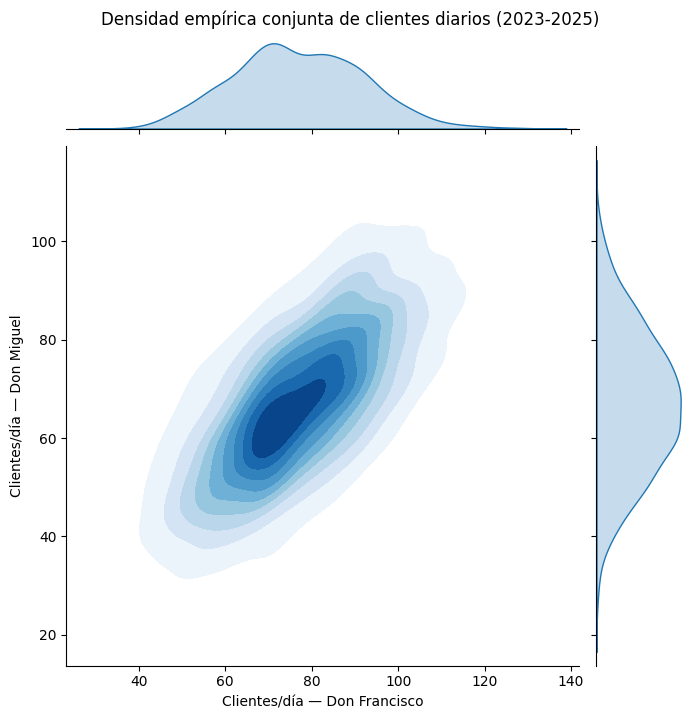


Correlación de Pearson entre los dos comercios: 0.6659
(Positiva y alta: comparten los efectos de año, mes y día de la semana)


In [38]:
# Parte d) — Densidad empírica conjunta de los dos comercios
#
# Para cada día del rango armamos el par (clientes Francisco, clientes Miguel)
# y graficamos la densidad conjunta empírica con sns.jointplot, exactamente
# como vimos en clase con el dataset de pingüinos.

import matplotlib.pyplot as plt
import seaborn as sns

# Pivot para tener una columna por propietario
df_conjunto = df.pivot_table(
    index="fecha",
    columns="propietario",
    values="clientes",
).reset_index()

# Jointplot con KDE: el mapa central es la densidad conjunta y los
# bordes superior y derecho muestran las marginales.
g = sns.jointplot(
    data=df_conjunto,
    x="Don Francisco",
    y="Don Miguel",
    kind="kde",
    fill=True,
    cmap="Blues",
    height=7,
)
g.set_axis_labels("Clientes/día — Don Francisco", "Clientes/día — Don Miguel")
plt.suptitle("Densidad empírica conjunta de clientes diarios (2023-2025)", y=1.02)
plt.show()

# Correlación de Pearson para cuantificar la dependencia
corr = df_conjunto[["Don Francisco", "Don Miguel"]].corr().iloc[0, 1]
print(f"\nCorrelación de Pearson entre los dos comercios: {corr:.4f}")
print("(Positiva y alta: comparten los efectos de año, mes y día de la semana)")
